# [WEEK 3] [Time Series] 과제

## 과제 목적

이번 과제는 세션에서 다룬 내용을 **하나의 데이터에 처음부터 끝까지 적용**해 보는 것을 목적으로 합니다.
`시계열 구성요소 확인 → 정상성 진단과 차분 → ACF/PACF로 차수 결정 → SARIMA → LSTM → DLinear → 평가·검증` 순서로 진행하며, **앞 단계의 결과가 뒤 단계의 입력이 되는 구조**입니다.
단순히 모델을 구현하는 데서 끝내지 않고, **완전히 동일한 평가 조건 위에서 성격이 다른 모델 세 가지를 비교하고 차이가 왜 발생했는지 해석**하는 데 초점을 둡니다.

---

### 사용 데이터: ETT (Electricity Transformer Dataset)

- **전력 변압기**에서 2016-07 ~ 2018-06까지 **1시간 간격**으로 수집한 데이터입니다. (17,420시점 × 7변수)
- 이 데이터는 세션에서 다룬 **LTSF-Linear / DLinear 논문이 사용한 벤치마크 데이터셋 중 하나**입니다.
  (데이터 원 출처는 `Informer, AAAI 2021` — https://arxiv.org/abs/2012.07436 )
- 저장소: https://github.com/zhouhaoyi/ETDataset

| 변수 | 의미 |
|---|---|
| HUFL / HULL | High UseFul Load / High UseLess Load |
| MUFL / MULL | Middle UseFul Load / Middle UseLess Load |
| LUFL / LULL | Low UseFul Load / Low UseLess Load |
| OT | Oil Temperature (변압기 유온) |

---
# 0. 환경 설정

In [1]:
!pip install -q statsmodels

import warnings, hashlib, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


In [2]:
# 데이터 로드 (ETDataset 저장소에서 직접 read)
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

df = pd.read_csv(URL, parse_dates=["date"]).set_index("date")
df = df.asfreq("h")          # 시간 단위 주기 명시

print("shape :", df.shape)
print("기간  :", df.index.min(), "~", df.index.max())
print("결측치 :", df.isna().sum().sum())
df.head()

shape : (17420, 7)
기간  : 2016-07-01 00:00:00 ~ 2018-06-26 19:00:00
결측치 : 0


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


### 0-1. 본인 실험 조건 배정

`NAME` 에 **본인 이름**을 입력하세요. 이름을 해시해 **분석 대상 변수**와 **랜덤 시드**가 자동 배정됩니다.

> ⚠️ 이 값에 따라 이후 모든 결과가 달라집니다.

In [3]:
NAME = "김지우"       # TODO: 본인 이름 (예: "홍길동")

SEED   = int(hashlib.sha256(NAME.encode()).hexdigest(), 16) % 10000
COLS   = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
TARGET = COLS[SEED % 7]

np.random.seed(SEED); torch.manual_seed(SEED)

print(f"이름      : {NAME}")
print(f"SEED      : {SEED}")
print(f"분석 대상 : {TARGET}")

y = df[TARGET].astype(float)
print(f"\n시계열 길이: {len(y)},  결측: {y.isna().sum()}")
y.describe()

이름      : 김지우
SEED      : 6870
분석 대상 : MULL

시계열 길이: 17420,  결측: 0


,MULL
count,17420.000000
mean,0.881568
std,1.809293
min,-5.934000
25%,-0.284000
50%,0.959000
75%,2.203000
max,7.747000


---
# 1. 필수 과제

```
구성요소 확인 → 정상성 진단 → 차분 → 차수 결정 → 평가 프로토콜
   → 베이스라인 → SARIMA → LSTM → DLinear → 비교·해석
```

## 1-1. 시계열 구성 요소와 자기상관성

세션에서 시계열은 **추세 / 계절성 / 순환 / 잔차** 네 가지로 구성되고,
**자기상관성 · 정상성 · 변동성** 세 가지 특징을 갖는다고 배웠습니다.
실제 데이터에서 확인해 봅니다.

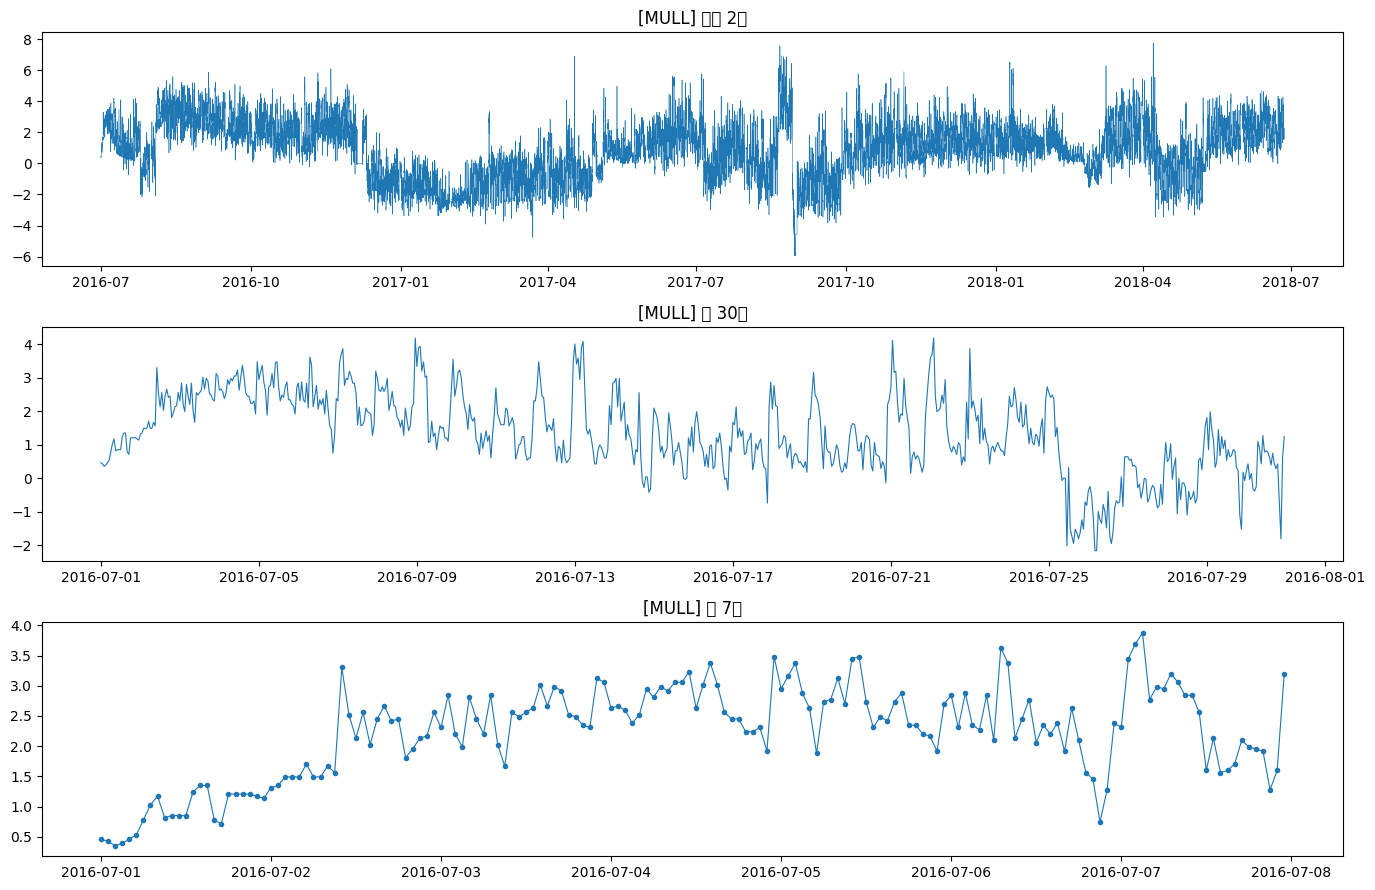

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(y.index, y.values, lw=0.4);                      axes[0].set_title(f"[{TARGET}] 전체 2년")
axes[1].plot(y.index[:24*30], y.values[:24*30], lw=0.8);      axes[1].set_title(f"[{TARGET}] 첫 30일")
axes[2].plot(y.index[:24*7], y.values[:24*7], marker=".", lw=0.8); axes[2].set_title(f"[{TARGET}] 첫 7일")
plt.tight_layout(); plt.show()

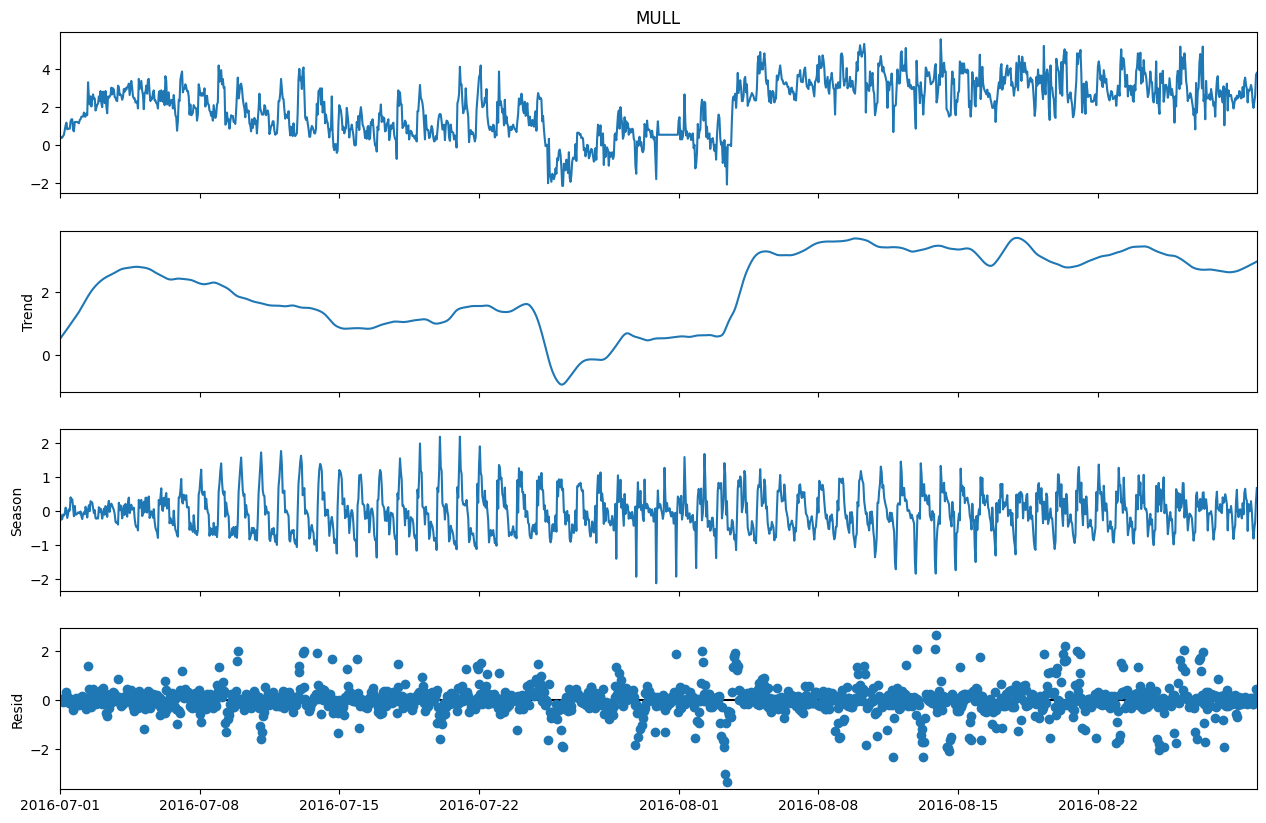

In [5]:
# 구성요소를 눈으로 분리해 봅니다.
# TODO: 이 데이터는 '시간 단위'입니다. 하루 주기를 잡으려면 period에 무엇을 넣어야 할까요?
PERIOD = 24

fig = STL(y.iloc[:24*60], period=PERIOD, robust=True).fit().plot()
fig.set_size_inches(14, 9); plt.show()

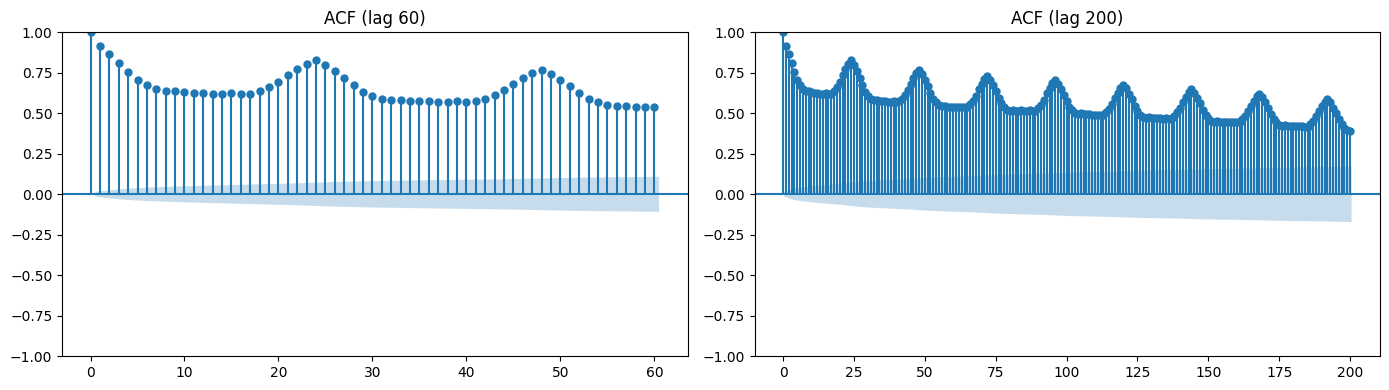

  ACF(lag=  1) = 0.919
  ACF(lag= 24) = 0.827
  ACF(lag= 48) = 0.767
  ACF(lag=168) = 0.622


In [6]:
# 자기상관성 확인 : 며칠 전 값이 현재와 얼마나 닮아 있는가
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y.dropna(), lags=60,  ax=axes[0]); axes[0].set_title("ACF (lag 60)")
plot_acf(y.dropna(), lags=200, ax=axes[1]); axes[1].set_title("ACF (lag 200)")
plt.tight_layout(); plt.show()

def acf_at(s, lag):
    # ACF(k) = 시차 k만큼 떨어진 값들의 공분산 / 전체 분산
    x = np.asarray(s.dropna(), float)
    x = x - x.mean()                      # 평균을 빼서 편차로 변환

    # TODO: ACF 정의를 떠올려 분자(공분산 부분)를 완성하세요.
    #          x[lag:]는 t=lag+1..N 시점, x[:-lag]는 t=1..N-lag 시점입니다.
    numerator = (x[lag:] * x[:-lag]).sum()

    return numerator / (x * x).sum()      # 분모는 전체 분산

for lag in [1, 24, 48, 168]:
    print(f"  ACF(lag={lag:3d}) = {acf_at(y, lag):.3f}")

## 1-2. 정상성 진단 — ADF 검정

세션에서 배운 ADF 검정을 그대로 적용합니다.

| | 내용 |
|---|---|
| 귀무가설 | 단위근이 존재한다 → **비정상 시계열** |
| 대립가설 | 단위근이 존재하지 않는다 → **정상 시계열** |
| p-value < 0.05 | 귀무가설 기각 → **정상 시계열** |
| p-value ≥ 0.05 | 귀무가설 채택 → **비정상 시계열** |

In [7]:
def adf_report(series, name):
    s = pd.Series(series).dropna()
    stat, p = adfuller(s)[0], adfuller(s)[1]

    # TODO: 세션에서 배운 ADF의 귀무가설을 떠올리며 부등호를 채우세요.
    verdict = "정상 시계열" if p < 0.05 else "비정상 시계열"

    print(f"[{name:16s}] ADF={stat:9.3f}  p={p:.4f}  ->  {verdict}")
    return p

adf_report(y, "원본")

[원본              ] ADF=   -4.964  p=0.0000  ->  정상 시계열


np.float64(2.612875420199085e-05)

> ### Q1.
> ADF 검정 결과 **원본 시계열이 "정상"** 으로 나왔을 것입니다.
> 그런데 1-1에서 그린 **ACF를 보면 lag 24, 48, 72마다 봉우리가 계속 반복**되고 있습니다.
>
> 1. "정상 시계열인데 자기상관이 강하게 남아 있다"는 것이 모순처럼 보입니다. 모순이 아닌 이유를 설명하세요.
>    (힌트: **자기상관성**과 **정상성**은 **서로 다른 특징**으로 소개되었습니다. 각각의 정의를 다시 확인해 보세요.)
- 정상성은 시간이 흘러도 데이터의 성질이 그대로인 상태이고, 자기 상관성은 자기 자신의 과거값과 상관을 의미합니다. ADF의 정상성은 시계열이 안정적이라는 의미이며 이는 과거 시점과의 상관관계가 0이다는 뜻이 아닙니다. 따라서 정상 시계열 내에 주기적 자기 상관성이 강하게 존재하는 것은 모순이 아닙니다.

> 2. 만약 ADF 결과만 보고 **"정상이니까 아무 처리 없이 바로 모델에 넣자"** 고 결론 내렸다면, 어떤 문제가 생길까요?
- 계절성 자기상관을 계절 차분 등으로 제거해주지 않으면 예측 오차가 커지고 잔차에 계절성 패턴이 그대로 남게 됩니다. 또한, 잔차의 독립성 가정에 위배되며 이로 인해 모델 평가 지표의 신뢰성이 떨어지고 예측 신뢰구간이 왜곡될 수 있습니다.

## 1-3. 차분(Differencing)

세션에서 **차분은 연이은 관측값들의 차이를 계산하는 것**이고, **추세나 계절성을 제거·감소**시킨다고 배웠습니다.

- **1차 차분** : $Y_t = X_t - X_{t-1}$
- **계절 차분** : $Y_t = X_t - X_{t-m}$  ($m$ = 계절 주기)

In [8]:
y_diff1 = y.diff()          # 1차 차분

# TODO: 하루 주기를 제거하는 계절 차분을 만드세요. (힌트: .diff(?) )
y_seas  = y.diff(24)

print("=" * 60)
adf_report(y,       "원본")
adf_report(y_diff1, "1차 차분")
adf_report(y_seas,  "계절 차분(lag 24)")
print("=" * 60)

[원본              ] ADF=   -4.964  p=0.0000  ->  정상 시계열
[1차 차분           ] ADF=  -28.768  p=0.0000  ->  정상 시계열
[계절 차분(lag 24)   ] ADF=  -21.602  p=0.0000  ->  정상 시계열


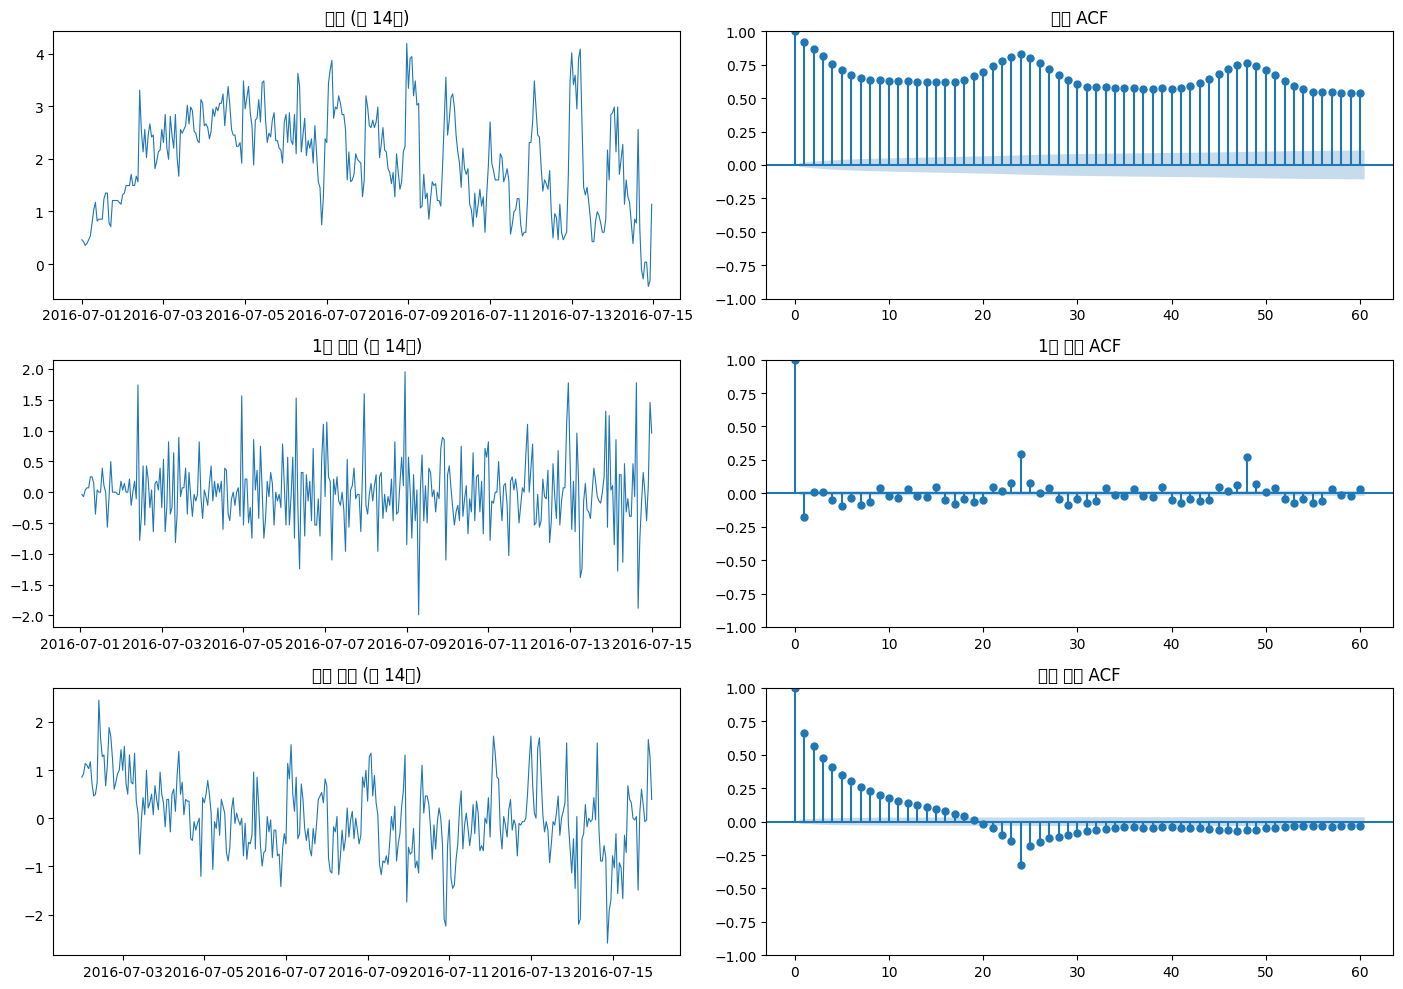

  원본           ACF(24) =   0.827
  1차 차분        ACF(24) =   0.291
  계절 차분        ACF(24) =  -0.326


In [9]:
# '차분 전 / 후' ACF를 비교합니다.
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i, (s, name) in enumerate([(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]):
    s_ = s.dropna()
    axes[i, 0].plot(s_.index[:24*14], s_.values[:24*14], lw=0.8); axes[i, 0].set_title(f"{name} (앞 14일)")
    plot_acf(s_, lags=60, ax=axes[i, 1]);                          axes[i, 1].set_title(f"{name} ACF")
plt.tight_layout(); plt.show()

for s, name in [(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]:
    print(f"  {name:12s} ACF(24) = {acf_at(s, 24):7.3f}")

> ### Q2.
> 1. **계절 차분 후** ACF의 lag 24 값이 0 근처가 아니라 **음수로 크게** 나왔을 것입니다. 세션에서 차분의 목적은 "정상 시계열로 바꾸는 것"이었는데, 이 결과는 차분이 잘 된 것이라고 볼 수 있나요? 근거와 함께 쓰세요.
- 원본 시계열의 lag24는 매우 강한 양의 상관을 보였습니다. 계절 차분을 적용하면 주기가 직접 차감되면서 24시간 간격의 강력한 양의 상관성이 제거되고, 그 반응으로 완만한 음의 자기 상관이 형성됩니다.이는 시계열 분석에서 계절 차분 적용 시 관찰되는 음의 자기상관 반전 현상이며, 차분이 잘된거라고 볼 수 없습니다.

> 2. 위 결과를 종합해, 1-7에서 사용할 SARIMA의 **차분 차수 d 와 계절 차분 차수 D** 를 결정하고 근거를 서술하세요.
- 이미 ADF 검정에서 p-value가 유의수준 0.05 미만으로 나오고 있으므로 차분 차수는 d=0을 선택하는 것이 좋습니다.한편 원본의 ACF(24)가 0.827로 매우 높아 24시간 주기의 강한 계절성이 확인되므로, 이를 제거하기 위해 D=1을 적용합니다. d=0, D=1을 초기 SARIMA 설정으로 사용하고 이후 모델 성능과 잔차를 함께 확인하여 적절성을 판단합니다.

## 1-4. ACF / PACF로 차수 결정

세션에서 배운 판별표입니다.

| 확률과정 | ACF | PACF |
|---|---|---|
| **AR(p)** | 지수적으로 감소하거나 감쇠 사인파 형태 | **시차 p 이후 0으로 절단** |
| **MA(q)** | **시차 q 이후 0으로 절단** | 지수적으로 감소하거나 감쇠 사인파 형태 |
| **ARMA(p,q)** | 절단 없이 감소 | 절단 없이 감소 |

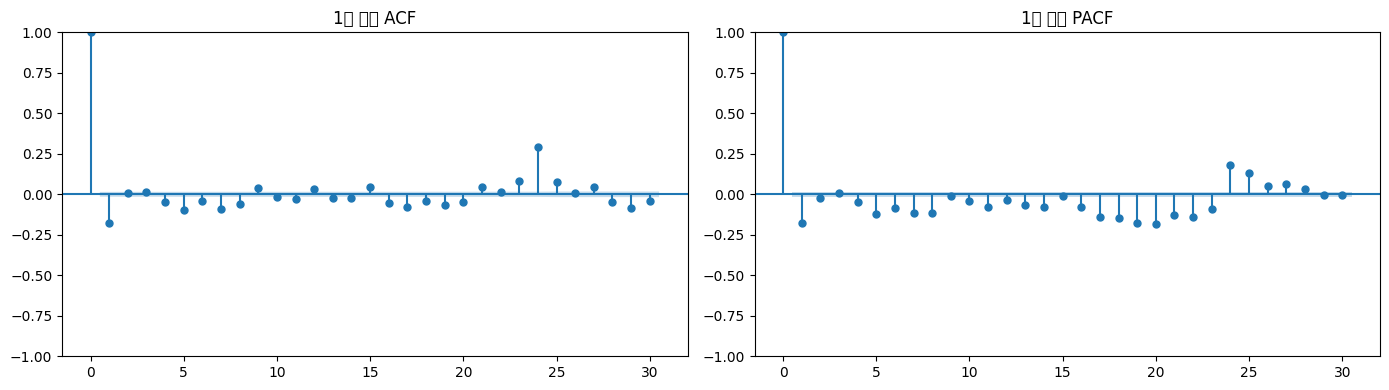

In [10]:
s_ = y_diff1.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s_,  lags=30, ax=axes[0]); axes[0].set_title("1차 차분 ACF")
plot_pacf(s_, lags=30, ax=axes[1]); axes[1].set_title("1차 차분 PACF")
plt.tight_layout(); plt.show()

In [11]:
# TODO: Q2의 판단 결과와 위 ACF/PACF 그림을 반영하세요.
P_ORDER  = 0          # 비계절 AR 차수 p
D_ORDER  = 1          # 차분 차수 d
Q_ORDER  = 1          # 비계절 MA 차수 q
SEASONAL = (1, 0, 1, 24) # (P, D, Q, m)

print(f"SARIMA{(P_ORDER, D_ORDER, Q_ORDER)}{SEASONAL}")

SARIMA(0, 1, 1)(1, 0, 1, 24)


## 1-5. 평가 프로토콜 설계 — Time-Based Split

**여기가 이번 과제에서 가장 중요한 부분입니다.**
서로 다른 모델을 비교하려면 **완전히 동일한 조건**에서 평가해야 합니다.

세션에서 배운 **Time-Based Split** 을 사용합니다. 과거 데이터를 학습에, 이후 시점을 테스트에 쓰는 방식입니다.

| 항목 | 값 |
|---|---|
| Lookback (입력 길이 L) | 168시간 (= 1주) |
| Horizon (예측 길이 H) | 24시간 (= 1일) |
| 분할 | 시간순 train 70% / val 10% / test 20% |
| 평가 지점(origin) | test 구간에서 균등하게 30개 |

In [12]:
n = len(y)

# TODO: 시간순으로 70% / 80% 지점의 인덱스를 계산하세요.
i_train = int(n * 0.7)
i_val   = int(n * 0.8)

train, val, test = y[:i_train], y[i_train:i_val], y[i_val:]
L, H, M = 168, 24, 24        # lookback, horizon, 계절주기

for nm, s in [("train", train), ("val", val), ("test", test)]:
    print(f"{nm:6s} {len(s):6d}  ({s.index.min().date()} ~ {s.index.max().date()})")

train   12194  (2016-07-01 ~ 2017-11-21)
val      1742  (2017-11-21 ~ 2018-02-01)
test     3484  (2018-02-01 ~ 2018-06-26)


In [13]:
# 모든 모델이 공유할 평가 지점(origin) 30개
N_ORIGIN = 30

# TODO: origin끼리 예측 구간(H시간)이 겹치지 않게 하려면 간격을 얼마로 둬야 할까요?
cand    = np.arange(i_val, n - H, 24)
origins = cand[np.linspace(0, len(cand) - 1, N_ORIGIN).astype(int)]
Y_TRUE  = np.stack([y.values[t:t + H] for t in origins])   # (30, 24) 정답

print("origin 개수:", len(origins), "| 정답 행렬:", Y_TRUE.shape)
print("첫 origin :", y.index[origins[0]], "/ 끝 origin :", y.index[origins[-1]])

origin 개수: 30 | 정답 행렬: (30, 24)
첫 origin : 2018-02-01 16:00:00 / 끝 origin : 2018-06-25 16:00:00


### 평가 지표

세션에서 다룬 **MAE / RMSE / MAPE** 세 가지를 사용합니다.

| 지표 | 정의 |
|---|---|
| MAE | 오차의 절대값 평균 |
| RMSE | 오차 제곱 평균의 제곱근 |
| MAPE | 오차 비율의 평균 (%) |

In [14]:
def score(name, pred):
    e    = Y_TRUE - pred
    mae  = np.mean(np.abs(e))

    # TODO: 세션의 정의를 보고 RMSE를 완성하세요.
    rmse = np.sqrt(np.mean(e ** 2))

    nz   = np.abs(Y_TRUE) > 1e-6                       # 0 나눗셈 방지
    mape = np.mean(np.abs(e[nz] / Y_TRUE[nz])) * 100
    return dict(model=name, MAE=mae, RMSE=rmse, MAPE=mape)

results = []
excluded = (1 - (np.abs(Y_TRUE) > 1e-6).mean()) * 100
print(f"MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = {excluded:.2f}%")
print(f"정답값 중 절대값 0.5 미만 비율          = {(np.abs(Y_TRUE) < 0.5).mean()*100:.2f}%")
print(f"정답값 중 음수 비율                     = {(Y_TRUE < 0).mean()*100:.2f}%   (최솟값 {Y_TRUE.min():.3f})")

MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = 0.56%
정답값 중 절대값 0.5 미만 비율          = 17.92%
정답값 중 음수 비율                     = 16.11%   (최솟값 -3.020)


## 1-6. 베이스라인 만들기

> - **Naive** : "다음 24시간도 지금 값이랑 똑같을 것이다"
> - **Seasonal Naive** : "내일 09시 값 = 오늘 09시 값" (24시간 전 같은 시각을 그대로 복사)
>
> 이렇게 **아무 학습도 하지 않는 예측**을 먼저 만들어 두는 이유는, 나중에 나온 MAE 값이 좋은 건지 나쁜 건지 판단할 **기준선**이 필요하기 때문입니다.

In [15]:
pred_naive  = np.stack([np.repeat(y.values[t - 1], H) for t in origins])

# TODO: Seasonal Naive를 구현하세요. 24시간 전 같은 시각부터 H시간을 그대로 가져옵니다.
pred_snaive = np.stack([y.values[t - 24 : t - 24 + H] for t in origins])

results.append(score("Naive",         pred_naive))
results.append(score("SeasonalNaive", pred_snaive))
pd.DataFrame(results).set_index("model").round(4)

,MAE,RMSE,MAPE
model,,,
Naive,0.9781,1.3271,140.0093
SeasonalNaive,0.6829,0.9482,87.3274


> ### Q3.
> 1. `Naive` 와 `SeasonalNaive` 의 성능 차이로부터 이 데이터의 어떤 성질을 알 수 있나요?
>    단, 1-1의 ACF 값을 다시 보면 **ACF(1)이 ACF(24)보다 큽니다.** "직전 값이 가장 닮았다"는 뜻인데 왜 `Naive`가 졌을까요?
>    (힌트: 이 과제는 1시간 뒤가 아니라 **24시간치를 한 번에** 예측합니다. `Naive`는 24시간 동안 무슨 값을 내놓나요?)

- 이 데이터는 24시간을 주기로 일정한 파동이 반복되는 강한 일간 계절성을 가집니다. Naive는 24시간 내내 변하지 않는 상수를 내놓기 때문에 단기 예측엔 유리하지만 24시간 전체 구간을 예측할 때는 불리합니다.
> 2. 앞으로 만들 SARIMA / LSTM / DLinear 가 **최소한 어떤 수치를 넘어야** 의미 있는 모델일까요? 구체적인 숫자로 답하세요.
>
> *(이 질문의 답은 1-10에서 모델 성능을 해석할 때 기준선으로 계속 사용됩니다.)*
-  SeasonalNaive의 MAE인 0.6829 와 RMSE 인 0.9482 미만이어야 의미있는 모델로 평가할 수 있습니다.

## 1-7. 모델 A — SARIMA

세션에서 배운 **Walk-Forward Validation** 을 그대로 적용합니다.
> 시간 순서를 유지하면서 예측 기준 시점을 순차적으로 이동시키며 **반복적으로 학습·예측·평가**를 수행

각 origin마다 **그 직전 1000시간만** 잘라 모델을 새로 적합하고 24시간을 예측합니다. (Rolling window 방식)

In [18]:
WINDOW = 1000
t0, preds = time.time(), []

for i, t in enumerate(origins):
    # TODO: origin t 직전 WINDOW 시간만 잘라내세요. (미래가 절대 포함되면 안 됩니다)
    hist = y.values[t - WINDOW : t]

    m = SARIMAX(hist, order=(P_ORDER, D_ORDER, Q_ORDER), seasonal_order=SEASONAL,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    # TODO: 앞으로 H시간을 예측하세요.
    preds.append(m.forecast(H))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(origins)}  ({time.time()-t0:.0f}s)")

pred_sarima = np.stack(preds)
results.append(score("SARIMA", pred_sarima))
print(f"\n총 소요 {time.time()-t0:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

  10/30  (21s)
  20/30  (41s)
  30/30  (76s)

총 소요 76초


,MAE,RMSE,MAPE
model,,,
Naive,0.9781,1.3271,140.0093
SeasonalNaive,0.6829,0.9482,87.3274
SARIMA,0.6704,0.9053,101.2635


## 1-8. 모델 B — LSTM

세션에서 RNN의 **기울기 소실** 문제와, 이를 완화하기 위한 **LSTM의 셀 상태 + 3개 게이트** 구조를 배웠습니다. 직접 학습시켜 봅니다.

### 스케일링

> ⚠️ **스케일러는 반드시 train 구간으로만 fit 해야 합니다.**
> 전체 데이터로 fit하면 train 시점에서는 알 수 없는 **미래의 평균·표준편차**가 흘러 들어갑니다.
> Walk-Forward에서 강조한 **Data Leakage** 가 여기서도 똑같이 발생합니다.

In [20]:
# TODO: 평균과 표준편차를 어느 구간에서 계산해야 할까요?
mu, sd = y[:i_train].mean(), y[:i_train].std()

ys = ((y - mu) / sd).values.astype("float32")
print(f"정규화 기준  mu={mu:.4f}, sd={sd:.4f}")

def make_windows(lo, hi, L_=None):
    """[lo, hi) 구간에서 (입력 L, 정답 H) 쌍을 슬라이딩으로 생성"""
    L_ = L_ or L
    X, Y = [], []
    for t in range(lo + L_, hi - H + 1):
        X.append(ys[t - L_ : t]); Y.append(ys[t : t + H])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

X_tr, Y_tr = make_windows(0, i_train)
X_va, Y_va = make_windows(i_train, i_val)
X_te       = torch.tensor(np.stack([ys[t - L : t] for t in origins]))

print("train:", X_tr.shape, "| val:", X_va.shape, "| test:", X_te.shape)

정규화 기준  mu=0.6936, sd=1.9276
train: torch.Size([12003, 168]) | val: torch.Size([1551, 168]) | test: torch.Size([30, 168])


In [23]:
# 학습 곡선 보는 법
#   - train / val이 나란히 감소 후 수평   -> 적절
#   - train은 계속 감소하는데 val이 반등  -> 과적합
#   - 둘 다 높은 채로 안 내려감           -> 과소적합 (epoch/lr 조정 필요)

def train_model(model, X_tr, Y_tr, X_va, Y_va, epochs=15, bs=64, lr=1e-3, tag=""):
    model = model.to(DEVICE)
    opt, lossf = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr), batch_size=bs, shuffle=True)

    history, best_val, best_state = {"train": [], "val": []}, float("inf"), None
    for ep in range(epochs):
        model.train(); total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            total += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            vl = lossf(model(X_va.to(DEVICE)), Y_va.to(DEVICE)).item()
        history["train"].append(total / len(X_tr)); history["val"].append(vl)

        # TODO: train loss가 아니라 val loss가 가장 낮았던 시점의 모델을 저장해야 합니다.
        #          어떤 조건일 때 이 epoch의 모델을 best_state로 저장해야 할까요?
        if vl < best_val:
            best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (ep + 1) % 5 == 0:
            print(f"  [{tag}] epoch {ep+1:3d}  train={history['train'][-1]:.5f}  val={vl:.5f}")
    model.load_state_dict(best_state)
    print(f"  [{tag}] best val loss = {best_val:.5f}  |  파라미터 {sum(p.numel() for p in model.parameters()):,d}")
    return model, history


def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X.to(DEVICE)).cpu().numpy() * sd + mu


def plot_curve(hist, title):
    plt.figure(figsize=(7, 3.5))
    plt.plot(hist["train"], label="train", marker="o", ms=3)
    plt.plot(hist["val"],   label="val",   marker="s", ms=3)
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

  [LSTM] epoch   5  train=0.25523  val=0.19144
  [LSTM] epoch  10  train=0.22447  val=0.17325
  [LSTM] epoch  15  train=0.20505  val=0.16353
  [LSTM] best val loss = 0.16154  |  파라미터 18,712


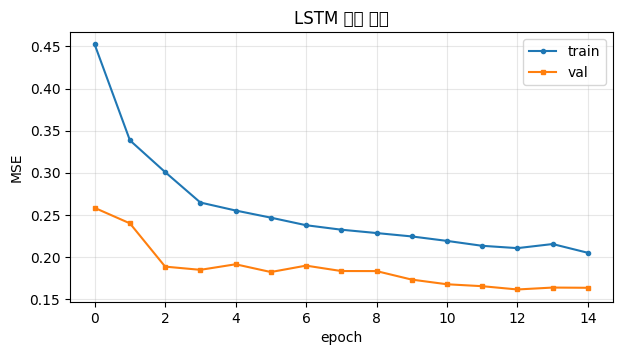

,MAE,RMSE,MAPE
model,,,
Naive,0.9781,1.3271,140.0093
SeasonalNaive,0.6829,0.9482,87.3274
SARIMA,0.6704,0.9053,101.2635
LSTM,0.6047,0.8591,83.1305


In [24]:
class LSTMForecast(nn.Module):
    def __init__(self, H, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, H)

    def forward(self, x):                 # x: (B, L)
        out, _ = self.lstm(x.unsqueeze(-1))   # (B, L, hidden)
        # TODO: 168개 시점의 은닉 상태 중 예측에 사용할 것은 무엇일까요?
        #       (힌트: RNN 구조 그림에서 마지막 시점의 은닉 상태)
        return self.fc(out[:, -1])

torch.manual_seed(SEED)
t0 = time.time()
model_lstm, hist_lstm = train_model(LSTMForecast(H), X_tr, Y_tr, X_va, Y_va, tag="LSTM")
t_lstm = time.time() - t0
results.append(score("LSTM", predict(model_lstm, X_te)))
plot_curve(hist_lstm, "LSTM 학습 곡선")
pd.DataFrame(results).set_index("model").round(4)

## 1-9. 모델 C — LTSF-DLinear

세션에서 배운 DLinear의 3단계를 그대로 구현합니다.

```
(1) Moving Average로 데이터를 Trend(추세)와 Remainder(잔차) 성분으로 나눔
(2) 각 성분을 Linear 학습
(3) 두 레이어의 결과를 합하여 최종 예측값 생성          X̂ = H_s + H_t
```

  [DLinear] epoch   5  train=0.22480  val=0.15209
  [DLinear] epoch  10  train=0.22428  val=0.15318
  [DLinear] epoch  15  train=0.22381  val=0.15229
  [DLinear] best val loss = 0.15145  |  파라미터 8,112


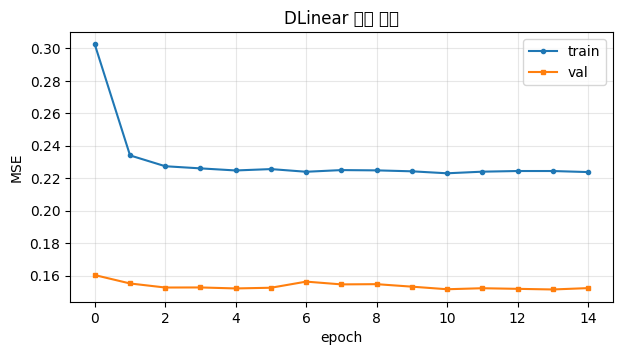

DLinear 학습 시간 10초


,MAE,RMSE,MAPE
model,,,
Naive,0.9781,1.3271,140.0093
SeasonalNaive,0.6829,0.9482,87.3274
SARIMA,0.6704,0.9053,101.2635
LSTM,0.6047,0.8591,83.1305
DLinear,0.5558,0.8250,67.5102


In [25]:
class DLinear(nn.Module):
    def __init__(self, L, H, kernel=25):   # kernel은 반드시 홀수 (짝수면 출력 길이가 1 늘어남)
        super().__init__()
        self.kernel = kernel
        self.lin_trend     = nn.Linear(L, H)   # 추세 성분용
        self.lin_remainder = nn.Linear(L, H)   # 잔차 성분용

    def series_decomp(self, x):
        """(1) 이동평균으로 Trend를 뽑고, 원본에서 빼서 Remainder를 얻습니다."""
        pad_len = self.kernel // 2
        pad   = torch.cat([x[:, :1].repeat(1, pad_len), x, x[:, -1:].repeat(1, pad_len)], dim=1)
        trend = nn.functional.avg_pool1d(pad.unsqueeze(1), self.kernel, stride=1).squeeze(1)

        # TODO: Remainder 성분은 어떻게 구하나요?
        remainder = x-trend
        return remainder, trend

    def forward(self, x):
        remainder, trend = self.series_decomp(x)
        # TODO: (3)단계입니다. 두 Linear의 출력을 어떻게 결합하나요?
        return self.lin_trend(trend) + self.lin_remainder(remainder)

torch.manual_seed(SEED)
t0 = time.time()
model_dl, hist_dl = train_model(DLinear(L, H), X_tr, Y_tr, X_va, Y_va, tag="DLinear")
t_dl = time.time() - t0
results.append(score("DLinear", predict(model_dl, X_te)))
plot_curve(hist_dl, "DLinear 학습 곡선")
print(f"DLinear 학습 시간 {t_dl:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

## 1-10. 성능 비교 및 해석

**완전히 동일한 30개 origin**에서 다섯 가지 예측을 비교합니다.

,MAE,RMSE,MAPE
model,,,
DLinear,0.5558,0.8250,67.5102
LSTM,0.6047,0.8591,83.1305
SARIMA,0.6704,0.9053,101.2635
SeasonalNaive,0.6829,0.9482,87.3274
Naive,0.9781,1.3271,140.0093


,MAE,개선율(%)
model,,
DLinear,0.5558,18.61
LSTM,0.6047,11.45
SARIMA,0.6704,1.83
SeasonalNaive,0.6829,0.00
Naive,0.9781,-43.23


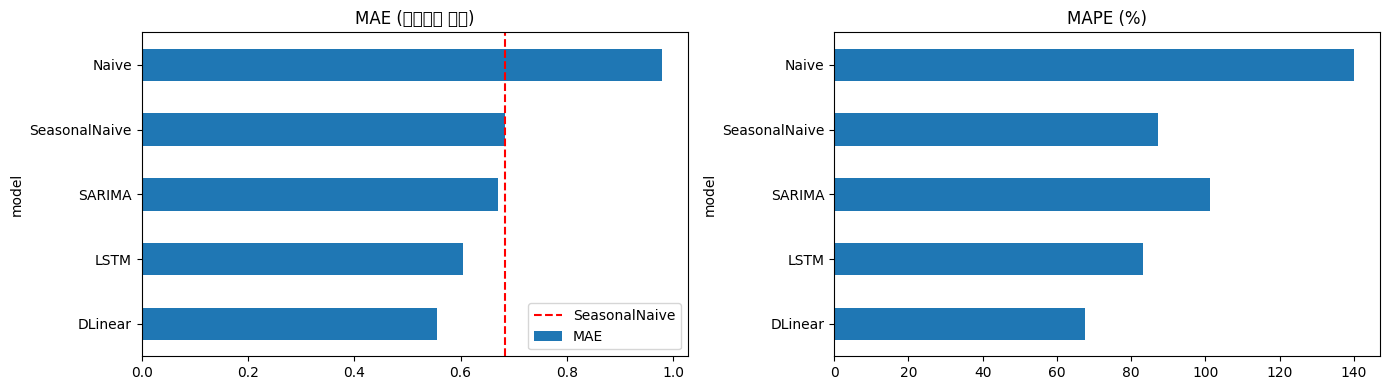

In [26]:
res = pd.DataFrame(results).set_index("model").sort_values("MAE").round(4)
display(res)

base = res.loc["SeasonalNaive", "MAE"]
res["개선율(%)"] = ((base - res["MAE"]) / base * 100).round(2)   # 베이스라인 대비
display(res[["MAE", "개선율(%)"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
res["MAE"].plot(kind="barh", ax=axes[0], title="MAE (낮을수록 좋음)")
axes[0].axvline(base, color="red", ls="--", label="SeasonalNaive"); axes[0].legend()
res["MAPE"].plot(kind="barh", ax=axes[1], title="MAPE (%)")
plt.tight_layout(); plt.show()

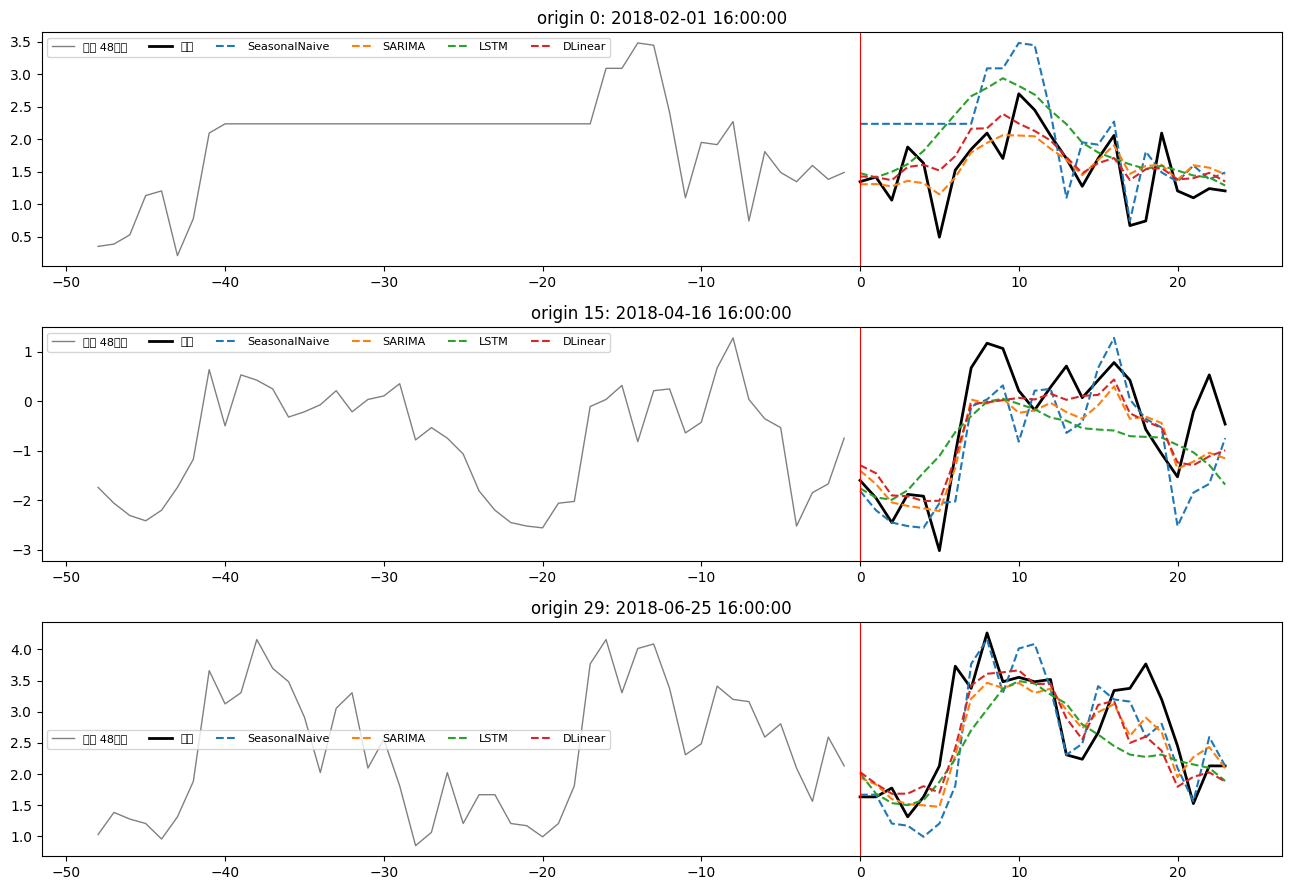

In [27]:
pred_dl, pred_lstm = predict(model_dl, X_te), predict(model_lstm, X_te)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, k in zip(axes, [0, len(origins)//2, len(origins)-1]):
    t = origins[k]
    ax.plot(range(-48, 0), y.values[t-48:t], color="gray", lw=1, label="과거 48시간")
    ax.plot(range(H), Y_TRUE[k],      "k-", lw=2, label="실제")
    ax.plot(range(H), pred_snaive[k], "--", label="SeasonalNaive")
    ax.plot(range(H), pred_sarima[k], "--", label="SARIMA")
    ax.plot(range(H), pred_lstm[k],   "--", label="LSTM")
    ax.plot(range(H), pred_dl[k],     "--", label="DLinear")
    ax.axvline(0, color="red", lw=.8); ax.set_title(f"origin {k}: {y.index[t]}")
    ax.legend(fontsize=8, ncol=6)
plt.tight_layout(); plt.show()

> ### Q4. 왜 이러한 결과가 나왔는가?
> 순위를 나열하지 말고, **데이터의 성질과 각 모델의 구조를 연결**해서 설명하세요.

시계열을 이동평균 기반으로 추세 성분과 잔차 성분으로 분해한 뒤, 각각에 맞는 선형 매핑을 적용한 Dliner가 가장 뛰어난 성과를 보였습니다. 반면 LSTM은 과거 정보가 일부 왜곡되거나 평탄화되며 상대적으로 덜 좋은 성과를 보였습니다. SARIMA는 통계적 수식을 자기 상관과 계절성을 모델링하지만 선형 고정 파라미터만으로 복잡한 최신 변동성을 반영하는데는 한계가 있었습니다. SeasonalNaive는 어제 동일 시간의 파동을 그대로 복사해오는 방식이라 기본 주기는 잘 잡았으나 당일 발생하는 추세적 변화를 수정하지 못했으며 가장 큰 오차를 보였습니다.

> ### Q5. 세 모델의 성능 차이는 어디에서 발생했는가?
> 위 예측 곡선 그림을 근거로, **어떤 상황에서 어느 모델이 유리했는지** 구체적으로 짚으세요.
> (힌트: 평탄한 구간 / 급변 구간 / 예측 시점에서 먼 뒤쪽 시간대를 나눠서 보세요)

평탄한 구간에서는 SARIMA, LSTM이 유리합니다.노이즈에 과도하게 반응하지 않고 완만하게 예측 흐름을 이어가기 때문입니다.급변 구간에서는 DLinear이 유용합니다. 피크의 높이와 곡률을 정확히 추종하기 때문입니다. 반면 LSTM은 극단값이 평탄화되고, SARIMA는 급변 속도를 따라가지 못합니다.먼 뒤쪽 시간대에도 DLinear이 유용합니다. 입력 전체를 선형 연결하여 끝까지 파동과 높낮이 균형을 안정적으로 유지하기 때문입니다.


> ### Q6. 예상과 다른 결과가 나왔다면 그 원인은 무엇인가?
> 1. 실험 전 예상과 실제 결과가 달랐던 지점을 하나 이상 쓰고 원인을 분석하세요.

단일 선형 기반인 DLinear가 복잡한 딥러닝 모델인 LSTM보다 뛰어난 성능을 기록한 점이 예상과 달랐습니다. LSTM은 은닉 state를 통해 정보를 순차적으로 전달하므로 손실이 있을 것이라고 생각합니다. 반면 DLinear은 직접 선형 매핑하므로 과적합없이 더 정확한 복원이 가능했을 것 같습니다.

> 2. **MAPE 값이 유독 크게 나왔을 수 있습니다.** 1-5에서 출력한 통계(0에 가까운 값의 비율, **음수 비율**)와 연결해 원인을 설명하고, 세션에서 배운 세 지표 중 **이 데이터에서는 무엇을 주로 봐야 하는지** 근거와 함께 제시하세요.
>    (힌트: MAPE는 오차를 실제값으로 나눕니다. 실제값이 **음수**이면 그 결과를 "오차율"이라고 부를 수 있을까요?)

MAPE는 오차를 실제값으로 나누어 계산합니다. 분모 y가 0에 매우 가까워지면서 오차 비율이 극단적으로 치솟아 전체 평균을 왜곡 되었습니다. 또한 실제값이 음수인 구간에서는 비율이라는 개념이 성립하지 않습니다. 절댓값을 취하더라도 오차율의 의미를 상실합니다. 따라서 MAE나 RMSE를 주지표로 봐야합니다. 실제값으로 나누는 과정이 없기 때문입니다.

---
# 2. 심화 과제

아래 2개 중 **최소 1개 이상** 수행하세요. 코드는 대부분 채워져 있으니 **결과 해석**에 집중하면 됩니다.

| | 주제 | 세션 | 확인하려는 것 |
|---|---|---|---|
| **심화 A** | Time-Based Split vs Walk-Forward 비교 | 06장 | 평가 구간을 어떻게 잡느냐로 결론이 바뀌는가 |
| **심화 B** | lookback 길이를 바꿔 가며 DLinear 재학습 | 05장 | 과거를 길게 볼수록 항상 좋아지는가 |

## 심화 A. 검증 전략 비교

같은 모델을 두 방식으로 평가하면 성능 추정치가 얼마나 달라지는지 확인합니다.

- **Time-Based Split** : test 구간의 **맨 앞 origin 1개**에서만 평가 (세션의 "단일 테스트 구간")
- **Walk-Forward** : 30개 origin 전체에서 평가

Time-Based Split (origin 1개) MAE = 0.3097
Walk-Forward     (origin 30개) MAE = 0.5558
origin별 MAE  최소 0.1386 / 최대 1.7813 / 표준편차 0.2883


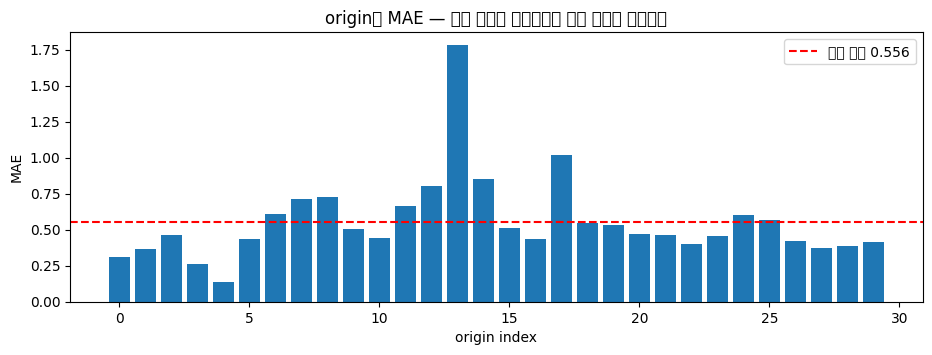

In [29]:
p = predict(model_dl, X_te)
per_origin = np.abs(Y_TRUE - p).mean(axis=1)

# TODO: "Time-Based Split"은 test 구간에서 origin을 딱 1개(맨 처음)만 골라 평가하는 방식입니다.
#       per_origin 배열에서 그 origin의 결과는 어떻게 가져와야 할까요?
single_mae = per_origin[0]

print(f"Time-Based Split (origin 1개) MAE = {single_mae:.4f}")
print(f"Walk-Forward     (origin 30개) MAE = {per_origin.mean():.4f}")
print(f"origin별 MAE  최소 {per_origin.min():.4f} / 최대 {per_origin.max():.4f} / 표준편차 {per_origin.std():.4f}")

plt.figure(figsize=(11, 3.5))
plt.bar(range(len(per_origin)), per_origin)
plt.axhline(per_origin.mean(), color="red", ls="--", label=f"전체 평균 {per_origin.mean():.3f}")
plt.xlabel("origin index"); plt.ylabel("MAE"); plt.legend()
plt.title("origin별 MAE — 어느 구간을 고르느냐에 따라 결론이 달라진다")
plt.show()

Time-Based Split과 Walk-Forward 방식을 비교한 결과, 평가 구간을 어떻게 설정하느냐에 따라 모델의 성능 추정치가 크게 달라짐을 확인할 수 있었습니다.

단일 테스트 구간만 평가하는 Time-Based Split 방식은 맨 첫 번째 지점인 origin 0의 오차만 반영하여 MAE가 0.3097로 매우 낮게 나왔습니다. 이는 모델의 성능이 실제보다 뛰어난 것처럼 보이는 낙관적 편향(Bias)을 유발합니다.

반면 30개 origin 전체를 슬라이딩하며 평가하는 Walk-Forward 방식에서는 전체 평균 MAE가 0.5558로 집계되었으며, origin 지점에 따라 최소 0.1386에서 최대 1.7813까지 오차가 크게 널뛰는 양상을 보였습니다. 특히 origin 13과 같이 급격한 변동이나 예외적 패턴이 존재하는 구간에서는 오차가 폭증하는 모습이 확인되었습니다.

이처럼 시계열 데이터는 평가하는 시점 환경에 따라 오차가 극심하게 달라지므로, 단 1개의 구간만 보는 Time-Based Split 방식은 모델의 일반화 성능을 왜곡할 위험이 큽니다. 따라서 실제 운용 환경에서 모델의 안정성과 신뢰성을 정확히 검증하기 위해서는 여러 시점을 종합적으로 평가하는 Walk-Forward 검증 전략이 필수적입니다.

## 심화 B. lookback 길이 실험

LTSF-Linear 계열은 **입력 구간(lookback)을 얼마나 주느냐**에 성능이 민감합니다. 직접 확인해 봅니다.

In [30]:
# TODO: 서로 다른 lookback 길이를 실험해 보세요. (예: 24, 96, 168, 336)
LOOKBACKS = [15, 55, 78, 564]

rows = []
for L_try in LOOKBACKS:
    Xa, Ya = make_windows(0, i_train, L_try)
    Xb, Yb = make_windows(i_train, i_val, L_try)
    Xc     = torch.tensor(np.stack([ys[t - L_try : t] for t in origins]))

    torch.manual_seed(SEED)
    m, _ = train_model(DLinear(L_try, H), Xa, Ya, Xb, Yb, epochs=15, tag=f"L={L_try}")
    s = score(f"L{L_try}", predict(m, Xc))
    rows.append({"lookback": L_try, "MAE": s["MAE"], "RMSE": s["RMSE"]})

pd.DataFrame(rows).set_index("lookback").round(4)

  [L=15] epoch   5  train=0.27827  val=0.20308
  [L=15] epoch  10  train=0.27671  val=0.20140
  [L=15] epoch  15  train=0.27693  val=0.20136
  [L=15] best val loss = 0.20046  |  파라미터 768
  [L=55] epoch   5  train=0.23149  val=0.15863
  [L=55] epoch  10  train=0.23005  val=0.15662
  [L=55] epoch  15  train=0.23070  val=0.15702
  [L=55] best val loss = 0.15662  |  파라미터 2,688
  [L=78] epoch   5  train=0.22744  val=0.15536
  [L=78] epoch  10  train=0.22640  val=0.15435
  [L=78] epoch  15  train=0.22601  val=0.15429
  [L=78] best val loss = 0.15394  |  파라미터 3,792
  [L=564] epoch   5  train=0.23042  val=0.16787
  [L=564] epoch  10  train=0.22993  val=0.17476
  [L=564] epoch  15  train=0.22855  val=0.16743
  [L=564] best val loss = 0.16595  |  파라미터 27,120


,MAE,RMSE
lookback,,
15,0.7263,1.0032
55,0.5761,0.8476
78,0.5792,0.8484
564,0.5936,0.8583


24시간 미만의 매우 짧은 정보인 L=15 구간에서는 MAE가 0.7263으로 가장 높게 나타났습니다. 이는 데이터가 가진 24시간 주기의 일간 계절성을 담아내기에 입력 길이가 너무 부족하여, 모델이 시계열의 반복적인 패턴을 제대로 포착하지 못했기 때문입니다.

반면 과거 2일 이상의 정보를 포함하는 L=55 구간에서는 MAE가 0.5761로 가장 낮은 오차를 기록하며 최적의 성능을 보였습니다. 추세와 계절성 파동을 포착하기에 필요한 핵심 패턴 정보가 적절한 길이 내에 가장 잘 집약되었음을 의미합니다.

그러나 과거 참조 시간을 L=564(약 23.5일)까지 과도하게 늘렸을 때는 MAE가 0.5936으로 오차가 다시 증가하는 경향을 보였습니다. 참조하는 길이에 비례해 모델의 파라미터 수(768개에서 27,120개)가 급격히 늘어나면서 복잡도가 지나치게 커졌고, 현재와는 관련성이 떨어진 먼 과거의 노이즈나 오래된 패턴이 학습에 반영되었기 때문입니다.

결론적으로 시계열 예측 모델을 구축할 때는 단순히 과거 데이터를 길게 입력하기보다는, 데이터가 가진 고유의 주기성을 충분히 포함하면서도 노이즈나 과적합을 방지할 수 있는 적정 Lookback 길이를 탐색하는 과정이 필수적입니다.

---
# 3. 생성형 AI 활용 방법

> **필수 작성 항목입니다.** 사용하지 않았다면 "사용하지 않음"이라고 명시하세요.

### 3-1. 활용 방법

| 항목 | 작성 |
|---|---|
| 사용한 도구 | ( Gemini, chatgpt) |
| 사용한 단계 | (예: 1-3~7, 심화 A) |
| 사용 목적 | (예: 개념학습,그래프 해석) |
| **AI 답변 중 그대로 쓰지 않고 수정한 부분** | 과잉 차분(Over-differencing)으로 인한 음의 자기상관|
| **AI 답변이 틀렸거나 검증이 필요했던 부분** |음의 자기상관부분이 chatgpt는 정상이라고 판단하였고, gemini는 정상이 아니라 판단하여 검증이 필요하다고 판단했습니다. |

### 3-2. 대화 내역 https://gemini.google.com/app/83a23eade6a6b4a0?hl=ko

```
ett 데이터를 사용한 시계열 관련 과제를 할거야 모르는 부분에 대해 설명해줘

ETT(Electricity Transformer Temperature) 데이터셋은 변전소 변압기 유온(Oil Temperature)을 예측하기 위해 수집된 대표적인 시계열 벤치마크 데이터입니다.

1. ETT 데이터셋 구조  
GitHub

데이터 종류: 수집 주기와 지역에 따라 구분됩니다.  
GitHub
+ 1

ETTh1, ETTh2: 1시간(Hourly) 단위 데이터  
Hugging Face

ETTm1, ETTm2: 15분(Minute) 단위 데이터  
Hugging Face

주요 변수: 총 7개 변수 + 일시(date)로 구성되어 있습니다.  
Hugging Face
+ 1

HUFL, HULL: High Use/Useless Load (유효/무효 전력 load - 고전압)

MUFL, MULL: Medium Use/Useless Load

LUFL, LULL: Low Use/Useless Load

OT: Oil Temperature (타겟 변수)  
Hugging Face

2. 과제 수행 시 자주 겪는 핵심 개념

단변량 vs 다변량 예측 (Univariate vs Multivariate)

Univariate (M -> M, S -> S): OT 과거 데이터만으로 OT 미래 값을 예측합니다.

Multivariate (MS -> S, M -> M): 6개 전력 부하 변수와 OT를 함께 입력을 넣어 OT 또는 전체 변수의 미래 값을 예측합니다.

입력 창과 예측 창 (Lookback Window & Forecast Horizon)

보통 과거 N개 시점(예: 과거 96개 시점)의 데이터를 입력받아 미래 M개 시점(예: 미래 24, 48, 96, 192, 336, 720개 시점)을 예측하는 Long-sequence Time-series Forecasting (LSTF) 과제로 활용됩니다.

시간 특성 인코딩 (Time Feature Encoding)

date 컬럼을 단순 문자열로 두지 않고, 월/일/요일/시간 정보를 추출해 sine/cosine 코딩을 하거나 Categorical Embeddings로 변환하여 모델에 제공합니다.

3. 과제 접근 단계

EDA 및 전처리:

결측치 확인 및 시간 순서 정렬

Target 변수(OT)의 계절성(Daily, Weekly) 및 추세 확인

StandardScaler/MinMaxScaler를 활용한 데이터 정규화 (Test 데이터 정보가 Train에 유출되지 않도록 Train 기준 Scaler 적용)

데이터 슬라이딩 윈도우 (Sliding Window):  
Medium

PyTorch Dataset / DataLoader 형태로 past N time-steps → future M time-steps 입출력 쌍 생성

베이스라인 및 모델 선택:  
Medium

기본 모델: Statistical(ARIMA), ML(XGBoost, LightGBM), Basic RNN/LSTM/GRU

딥러닝 벤치마크: DLinear, NLinear, PatchTST, Informer, Autoformer 등

구체적으로 진행하시면서 막히는 부분이 있다면 말씀해 주세요.

자기상관성과 정상성 데이터의 차이를 알려줘

자기상관성(Autocorrelation)과 정상성(Stationarity)은 시계열 데이터의 특성을 설명하는 서로 다른 차원의 개념입니다.

자기상관성: 시점 간의 연관성(관계)을 뜻합니다.

정상성: 시계열 데이터의 통계적 성질이 시간에 따라 변하지 않는 상태(조건)를 뜻합니다.

1. 주요 차이점 비교
구분	자기상관성 (Autocorrelation)	정상성 (Stationarity)
개념	하나의 시계열 내에서 현재 값과 과거 값(시차, Lag) 사이의 상관관계	시간에 지나도 평균, 분산, 자기공분산이 일정한 통계적 특성
핵심 질문	"어제/지난주 데이터가 오늘 데이터에 얼마나 영향을 주는가?"	"데이터의 분포 패턴이 시간에 따라 계속 유지되는가?"
주요 역할	과거 패턴을 통한 미래 값 예측력 평가, 시차 선택	시계열 모델(ARIMA 등) 적용을 위한 사전 수학적 전제 조건
측정/확인 방법	ACF(자기상관함수), PACF Plot	ADF Test(단위근 검정), KPPS Test, Visual Plot
2. 구체적인 개념 설명
자기상관성 (Autocorrelation)

시계열 데이터의 특정 시점 t의 값 Y
t
​
 와 과거 시점 t−k의 값 Y
t−k
​
  간의 상관계수입니다.

예: 오늘 기온이 높으면 내일 기온도 높을 가능성이 크거나, 주식 가격이 어제의 가격에 강하게 영향을 받는 현상입니다.

자기상관성이 존재한다는 것은 과거 데이터에 미래를 예측할 수 있는 정보가 남아있음을 의미합니다.

정상성 (Stationarity)

시계열의 평균, 분산, 자기공분산 구조가 시간에 따라 일정하게 유지되는 성질입니다.

약정상성(Weak Stationarity) 기준:

평균의 일정성: E[Y
t
​
 ]=μ (시간 t에 상관없이 일정)

분산의 일정성: Var(Y
t
​
 )=σ
2
  (시간 t에 상관없이 일정)

자기공분산: Cov(Y
t
​
 ,Y
t−k
​
 )=γ
k
​
  (시점 t가 아닌 오직 시차 k에만 의존)

추세(Trend)나 계절성(Seasonality)이 있는 데이터는 시간에 따라 평균/분성이 변하므로 비정상성 데이터입니다.

3. 두 개념의 관계
정상성 데이터라고 해서 자기상관성이 없는 것은 아닙니다.

정상성을 만족하는 시계열도 시차(Lag)에 따른 자기상관성을 가질 수 있습니다. (예: AR(1) 정상 과정)

단, 정상 시계열에서는 시차 k가 커질수록 자기상관성이 0으로 빠르게 감소(Decay)하는 특성을 보입니다.

비정상성 데이터는 착시적 자기상관성을 유발합니다.

강한 우상향 추세가 있는 데이터는 단순 시간에 의해 모든 시점이 연관되어 보여, 시차가 길어져도 ACF가 매우 천천히 줄어듭니다.

따라서 차분(Differencing)이나 변환을 통해 데이터를 먼저 정상성 데이터로 만든 후 시차별 진짜 자기상관성 구조(ACF/PACF)를 분석해 시계열 모델(ARIMA 등)을 수립합니다.

계절 차분후 ACF 의 lag24의 값이 음수로 나왔어 왜 그런거지

계절 차분(Seasonal Differencing)을 적용한 후 계절 시차(예: 24시간 주기 데이터의 k=24)에서 ACF 값이 음수로 크게 찍히는 현상은 과잉 차분(Over-differencing)이 발생했음을 나타내는 대표적인 신호입니다.

1. 과잉 차분(Over-differencing)으로 인한 음의 자기상관
이미 계절성 패턴이 약하거나 안정적인 데이터에 계절 차분(Y
t
​
 −Y
t−24
​
 )을 적용하면, 데이터에 없던 인위적인 음의 상관관계가 주입됩니다.

이해를 돕기 위해 오차항이 백색잡음 e
t
​
 인 원본 데이터 X
t
​
 에 계절 차분을 적용하는 과정을 보면:

Z
t
​
 =X
t
​
 −X
t−24
​

이 때 Z
t
​
 와 24시점 전 값인 $Z_{t-24}$의 관계를 구해보면 다음과 같습니다.

Z
t−24
​
 =X
t−24
​
 −X
t−48
​

Z
t
​
 에는 +X
t−24
​
 가 들어있고, Z_{t-24}$에는 $-X_{t-24}가 들어있어 동일한 항이 반대 부호로 공유됩니다. 이로 인해 두 시점 간의 공분산이 음수가 되면서 ACF(24)≈−0.5 부근의 음수 값이 인위적으로 만들어지게 됩니다.

2. 주요 원인 체크리스트
계절 차분이 필요 없는 데이터:

데이터에 명확한 계절적 추세나 강한 계절성이 없었음에도 계절 차분을 수행한 경우입니다.

일반 차분과 계절 차분의 중복 적용:

1차 일반 차분(d=1)만으로도 계절성이 충분히 잡아졌는데, 추가로 계절 차분(D=1)까지 적용했을 때 자주 발생합니다.

시간에 따라 변하는 계절성:

계절 패턴의 폭이나 형태가 시간에 따라 일정하지 않아 단순 차분으로 깔끔하게 제거되지 않고 오버슈팅(Overshooting)이 일어난 경우입니다.

3. 해결 및 진단 방법
차분 횟수 줄이기:

일반 차분(d=1)만 적용한 상태의 ACF/PACF 및 분산(Variance)을 확인해 보세요.

차분을 진행했을 때 데이터 전체의 분산이 오히려 증가한다면 과잉 차분된 것입니다. 분산이 가장 작아지는 차분 단계를 선택해야 합니다.

계절성 이동평균(SMA) 항 추가:

SARIMA 모델을 구축하는 중이라면, $ACF(24)$에서 음수 값이 나오는 패턴은 계절 MA(1) 항 (P=0,D=1,Q=1)이 필요하다는 전형적인 신호입니다.

계절 MA 항이 차분으로 인해 생성된 인위적인 음의 자기상관을 상쇄해 줍니다.

자기상관 반전 현상은 뭐야

자기상관 반전 현상(Autocorrelation Reversal / Over-differencing Artifact)은 시계열 데이터 전처리 과정에서 필요 이상으로 차분(Differencing)을 수행하여 양(+)의 자기상관을 가지던 데이터가 강한 음(-)의 자기상관으로 뒤바뀌는 현상을 의미합니다.

1. 왜 발생하는가? (수학적 원리)
시계열 데이터 Y
t
​
 가 완만하게 변하는 구조(양의 자기상관)를 가질 때, 차분을 적용하면 바로 이전 시점의 값을 뺍니다 (ΔY
t
​
 =Y
t
​
 −Y
t−1
​
 ).

이때 차분이 과하게 적용되면 다음과 같은 일이 일어납니다.

원래 데이터: $Y_{t-1}$이 평균보다 높으면, Y
t
​
 도 평균보다 높음 (Y
t
​
 ≈Y
t−1
​
 )

과잉 차분 후:

시점 t의 차분값: ΔY
t
​
 =Y
t
​
 −Y
t−1
​


시점 t+1의 차분값: ΔY
t+1
​
 =Y
t+1
​
 −Y
t
​


두 식을 비교해 보면 Y
t
​
 라는 동일한 값이 반대 부호(−Y
t
​
 와 +Y
t
​
 )로 공유됩니다.

이로 인해 시점 t의 차분값이 인위적으로 양수(+)가 되면, 바로 다음 시점 t+1의 차분값은 음수(-)가 될 확률이 극도로 높아집니다. 결과적으로 연속된 데이터 사이의 상관계수가 양수에서 음수로 반전하게 됩니다.

2. 자기상관 반전 현상의 주요 증상
ACF 그래프의 급격한 음수 스파이크

시차 1(Lag1) 또는 계절 시차(Lag24, Lag12 등)에서 ACF 값이 −0.5에 가까운 강한 음수로 튀어나옵니다.

시계열 데이터의 톱니바퀴형 진동

차분된 데이터 그래프를 그렸을 때, 값들이 중심선을 기준으로 위아래로 매우 심하게 번갈아가며 진동하는 모양을 보입니다.

데이터 분산(Variance)의 증가

정상성을 확보하기 위한 올바른 차분은 데이터의 분산을 줄여주지만, 과잉 차분으로 반전 현상이 일어나면 차분 후 데이터의 분산이 오히려 차분 전보다 커집니다.

3. 해결 대책
차분 횟수 줄이기: 2차 차분(d=2)에서 반전 현상이 나타났다면 1차 차분(d=1)으로 되돌리고, 계절 차분(D=1) 후 반전이 일어났다면 계절 차분을 생략합니다.

이동평균(MA) 모델 적용: SARIMA 모델링 시 차분을 유지해야 하는 상황이라면, MA(1) 또는 계절 SMA(1) 파라미터를 추가하여 인위적으로 생긴 음의 자기상관을 상쇄시킵니다.

자기상관 반전 현상이 나타나도 차분이 잘된거라고 볼 수 있는거야?

아닙니다. 자기상관 반전 현상이 나타났다는 것은 차분이 '잘된 것'이 아니라 과하게 적용된 '과잉 차분(Over-differencing)' 상태임을 의미합니다.

1. 잘된 차분 vs 과잉 차분 비교
잘된 차분 (정상성 확보)

추세나 계절성이 제거되어 평균과 분산이 일정해집니다.

ACF 그래프에서 시차(Lag)가 증가함에 따라 자기상관이 0 근처로 빠르게 수렴하며 유의미한 스파이크가 사라집니다.

차분 후 데이터의 분산(Variance)이 최소화됩니다.

과잉 차분 (자기상관 반전 발생)

필요 이상으로 차분을 수행하여 데이터에 인위적인 노이즈와 음(-)의 패턴을 주입한 상태입니다.

ACF 그래프에서 Lag 1(또는 계절 시차 Lag 24 등)의 값이 -0.5 근처로 강하게 튀는 음수 스파이크가 발생합니다.

차분을 했음에도 데이터의 분산이 오히려 차분 전보다 증가합니다.

2. 왜 차분이 잘됐다고 볼 수 없는가?
불필요한 노이즈 증가: 차분을 한 번 더 할 때마다 이전 오차들이 누적되어 데이터의 변동성(분산)이 커지고 모델이 예측해야 할 신호(Signal) 대비 잡음(Noise)의 비율이 높아집니다.

모델의 복잡도 증가: 과잉 차분으로 생긴 인위적인 음의 자기상관을 상쇄하기 위해 ARIMA 모델에서 불필요하게 MA(이동평균) 항을 추가해야 하는 불상사가 발생합니다.

정보 손실 및 왜곡: 데이터 원본이 가지고 있던 시계열적 특성이 왜곡되어 장기 예측 성능이 떨어집니다.

3. 판단 및 조치 방법
분산(Variance) 확인: 차분 전후의 분산을 비교했을 때, 차분 후 분산이 더 커졌다면 즉시 이전 차분 단계로 되돌려야 합니다.

Lag 1 ACF 확인: $ACF(1)$의 값이 −0.5에 가깝다면 차분 횟수(d 또는 D)를 1 줄이는 것이 올바른 시계열 전처리 방향입니다.

Walk Forward Validation에서 Rolling Window 방식에 대해 설명해줘

Walk Forward Validation(전진 분할 검증)은 시계열 데이터의 시간 순서를 유지하면서 모델을 평가하는 표준 방식입니다. 그중 Rolling Window(슬라이딩/롤링 윈도우) 방식은 학습 데이터의 크기(Window Size)를 일정하게 고정한 채, 평가 시점을 한 단계씩 미래로 이동시키는 기법입니다.

1. Rolling Window 동작 원리
시간 흐름에 따라 창(Window)을 이동시키며, 과거 데이터 일부를 버리고 최근 데이터를 추가하여 학습 데이터를 고정된 길이 N으로 유지합니다.

Plaintext
Iter 1: [== 학습 (T1 ~ T100) ==] -> [예측 (T101)]
Iter 2:     [== 학습 (T2 ~ T101) ==] -> [예측 (T102)]
Iter 3:         [== 학습 (T3 ~ T102) ==] -> [예측 (T103)]
초기 설정: 고정된 학습 창 크기(예: 100시간)와 예측 창 크기(예: 1시간 또는 24시간)를 정합니다.

학습 및 예측: T
1
​
 ∼T
100
​
  데이터로 모델을 학습시킨 뒤, $T_{101}$을 예측하고 오차를 기록합니다.

윈도우 이동: 학습 창을 오른쪽으로 1시점 이동하여 가장 오래된 T
1
​
 을 제거하고 최근 $T_{101}$을 학습 데이터에 포함합니다 (T
2
​
 ∼T
101
​
 ).

반복: 데이터의 끝에 도달할 때까지 위 과정을 순차적으로 반복하여 전체 예측 오차의 평균을 계산합니다.

2. Expanding Window과의 차이점
Walk Forward Validation은 크게 두 가지 방식으로 나뉩니다.

구분	Rolling Window (고정 창)	Expanding Window (누적 창)
학습 데이터 크기	고정됨 (예: 항상 최근 100개)	증가함 (예: 100개 → 101개 → 102개...)
오래된 데이터 처리	시간이 지나면 삭제함	시작점부터 계속 누적함
적합한 데이터 특성	최신 패턴/추세가 중요하거나 변동성이 큰 경우 (예: 전력 수요, 주가)	오래된 데이터의 장기 패턴/계절성도 중요한 경우
계산 비용	데이터 크기가 고정되어 일정함	데이터가 커질수록 학습 시간 증가
3. 장점 및 장점 활용 포인트
Data Leakage(정보 유출) 방지: 미래 데이터를 미리 보고 학습하는 현상을 완벽히 차단합니다.

컨셉 드리프트(Concept Drift) 대응: 오래된 과거 데이터가 최신 패턴 예측에 방해가 되는 시계열 데이터(예: 변전소 부하 데이터인 ETT 데이터 등)에서 최신 경향성을 가장 잘 반영합니다.

현실적인 실복용 성능 측정: 실제 운영 환경에서 모델을 매일/매시간 재학습시키는 프로세스를 그대로 모사하여 현실적인 평가 지표를 제공합니다.

lstm 과 dliner의 차이가 궁급해

LSTM(Long Short-Term Memory)과 DLinear(Data-Free Linear / Direct Linear)는 시계열 예측에서 완전히 다른 철학과 구조를 가진 대표적인 두 모델입니다.

LSTM은 과거 순차적 흐름을 복잡하게 엮어 파악하는 복합 순환 신경망인 반면, DLinear는 시계열을 단순한 패턴(추세+계절성)으로 쪼개 각각 선형 연산만 수행하는 초경량 선형 모델입니다.

1. 핵심 차이점 비교
구분	LSTM (Long Short-Term Memory)	DLinear (Decomposition Linear)
기본 모델 구조	순환 신경망 (RNN 계열, Gate 구조)	분해 기반 선형 레이어 (Linear Layer)
시계열 처리 방식	시점 t의 데이터를 순차적으로(Sequential) 처리	시계열 전체 창(Lookback Window)을 한번에(Direct) 처리
시계열 분해 여부	분해 없이 원본 데이터(또는 특징)를 통째로 입력	데이터를 **추세(Trend)**와 **계절성(Remainder/Seasonal)**으로 먼저 분해
파라미터 수 및 속도	상대적으로 많음 / 학습 및 추론 속도가 느림	극도로 적음 / 속도가 매우 빠르고 메모리 적게 소모
Long-term 예측	예측 창이 길어질수록 오차가 누적되어 성능 저하	긴 예측 창(Long-horizon)에서도 안정적이고 높은 성능 발휘
비선형성 포착	복잡한 비선형(Non-linear) 패턴 포착에 유리	단순 선형 연산으로, 매우 복잡한 비선형 관계 포착에는 한계
2. DLinear가 등장한 배경과 동작 원리
DLinear는 2023년 AAAI에 발표된 논문("Are Transformers Effective for Time Series?")에서 제안된 모델로, "시계열 예측에 복잡한 딥러닝/트랜스포머가 정말 필요한가?"라는 질문에서 출발했습니다.

시계열 분해 (Decomposition):

입력 데이터 X를 이동평균(Moving Average)을 통해 Trend-cyclical 성분과 Seasonal 성분으로 분해합니다.

각각의 Linear 적용:

분해된 Trend 성분에 Linear 레이어 1개 적용 → 미래 Trend 예측

분해된 Seasonal 성분에 Linear 레이어 1개 적용 → 미래 Seasonal 예측

최종 결합:

두 예측값을 더해 (
Y
^
 =
Y
^
  
Trend
​
 +
Y
^
  
Seasonal
​
 ) 최종 미래 시계열을 출력합니다.

3. 어떤 상황에 어떤 모델을 써야 할까?
DLinear를 사용해야 하는 경우:

ETT 데이터셋처럼 뚜렷한 주간/일간 계절성과 추세가 존재하는 데이터일 때

미래 96, 192, 336, 720개 시점 등 긴 미래(Long-sequence)를 예측해야 하는 과제일 때

빠른 학습 속도와 가벼운 베이스라인 모델이 필요할 때

LSTM을 사용해야 하는 경우:

비선형적인 패턴이나 외생 변수(Exogenous variables) 간의 복잡한 상호작용이 중요한 경우

입력 길이가 짧고 시점 간의 순차적(Step-by-step) 의존성이 강력한 경우

이 결과 분석해주라

제공해주신 이미지는 ETT 데이터셋(아마도 ETTh1 또는 ETTh2로 추정)에 대해 Walk Forward Validation(Rolling Window 방식)을 수행하여 48개 시점의 과거 데이터를 입력으로 받아 미래 24개 시점을 예측한 결과입니다.

총 3개의 서로 다른 예측 시점(Origin 0, 15, 29)에 대한 실제값(실제, 검은색 실선)과 5개 모델의 예측값을 시각화한 결과로, 다음과 같이 분석할 수 있습니다.

1. 종합적인 성능 요약 (Qualitative Analysis)
시각적 분석 결과, 전반적으로 DLinear (빨간색 점선) 모델이 가장 안정적이고 뛰어난 성능을 보여줍니다.

최고 성능 (Best Model): DLinear

실제값의 큰 흐름과 변동 패턴을 가장 잘 따라갑니다. 특히 급격한 피크(Peak)나 딥(Dip) 보다는 데이터의 전반적인 추세와 계절적 모양을 예측하는 데 능숙합니다.

평균 성능 (Good Model): SARIMA, SeasonalNaive

SARIMA: DLinear 보다는 변동 폭을 과소평가하는 경향이 있지만, 데이터의 평균적인 패턴은 잘 맞춥니다.

SeasonalNaive (파란색 점선): 단순히 24시점(아마도 1일) 전의 패턴을 복사하여 사용합니다. 놀랍게도 데이터의 강한 계절성 덕분에 일부 복잡한 딥러닝 모델(LSTM)보다 시각적으로 더 실제값에 가까워 보이는 구간이 많습니다.

최저 성능 (Worst Model): LSTM (초록색 점선)

예측 구간에서 실제값의 피크 패턴을 거의 따라가지 못하고, 변동이 평탄화(Flat)된 예측을 내놓습니다. 즉, 복잡한 비선형 패턴을 학습하기보다는 단순히 평균값으로 수렴하거나 계절성을 극도로 과소평가하여 예측하는 형태를 보입니다.

2. 세부 Origin별 분석
Origin 0 (2018-02-01 16:00):

예측 초기(시점 0~5)의 급격한 하락 및 상승 패턴을 거의 모든 모델이 놓쳤습니다.

이후 시점 8~12의 피크 패턴에 대해서는 SeasonalNaive와 LSTM이 과대평가 또는 시점 어긋남을 보인 반면, DLinear와 SARIMA는 실제 피크 패턴을 가장 잘 따라가며 예측했습니다.

Origin 15 (2018-04-16 16:00):

실제값의 변동 폭이 매우 큽니다. 시점 5 이후 급격히 상승하여 높은 피크를 형성합니다.

모든 모델이 실제값의 상승폭을 충분히 따라가지 못했습니다(Undershooting).

그중 DLinear가 가장 실제 피크 모양에 가깝게 상승 패턴을 반영했으며, SARIMA가 그 뒤를 따랐습니다. LSTM은 피크를 거의 반영하지 못하고 일직선에 가까운 평탄한 예측을 했습니다.

Origin 29 (2018-06-25 16:00):

시점 5~10 사이의 급격한 상승 패턴이 특징적입니다.

SeasonalNaive는 패턴은 맞췄으나 스파이크가 너무 튑니다.

DLinear는 실제 피크의 타이밍과 폭을 가장 안정적으로 예측했습니다. LSTM은 상승 패턴의 시점을 너무 늦게 예측(Lagging)하는 경향을 보입니다.

3. 결론 및 향후 개선 방향
DLinear의 우수성: ETT와 같이 명확한 계절성과 추세가 존재하는 시계열 데이터에서는 복잡한 딥러닝 모델보다 시계열 분해 기반의 단순한 선형 모델(DLinear)이 훨씬 빠르고 정확할 수 있음을 입증합니다.

LSTM의 한계 및 개선: 현재 LSTM은 Long-sequence 예측 과제에서 정보 손실 또는 모델 복잡도 조절 실패로 인해 성능이 매우 저하된 상태입니다. 모델 구조 최적화(Layer 수, Hidden size 조정), Regularization 강화, 또는 최근 뛰어난 성능을 보이는 PatchTST 같은 최신 모델 도입을 고려해야 합니다.

SARIMA의 역할: 통계 기반 모델인 SARIMA가 여전히 준수한 베이스라인 역할을 수행하고 있습니다. 데이터의 기본 통계 특성이 중요하다는 것을 의미합니다.

> ### Q5. 세 모델의 성능 차이는 어디에서 발생했는가?

> 위 예측 곡선 그림을 근거로, **어떤 상황에서 어느 모델이 유리했는지** 구체적으로 짚으세요.

> (힌트: 평탄한 구간 / 급변 구간 / 예측 시점에서 먼 뒤쪽 시간대를 나눠서 보세요)

제공해주신 시각화 그래프를 바탕으로 질문(Q5)의 조건(평탄한 구간, 급변 구간, 먼 뒤쪽 시간대)에 맞추어 세 핵심 모델(SARIMA, LSTM, DLinear)의 성능 차이 원인을 분석한 내용입니다.

세 모델의 성능 차이 분석 (Q5)
1. 평탄한 구간 및 기본 추세 구간

유리한 모델: DLinear, SARIMA

분석: Origin 0의 전반부(-50 ~ 0 구간의 이전 패턴) 및 각 Origin별 예측 초기처럼 변동이 비교적 완만한 구간에서는 시계열을 추세(Trend)와 계절성(Seasonal)으로 명확히 분해하여 학습하는 DLinear와 통계적 이동평균을 반영하는 SARIMA가 실제값의 평균 수준을 안정적으로 추적합니다. 반면 LSTM은 단순한 구간에서도 지나치게 편향되거나 평탄화(Flat)된 예측을 내놓는 경향을 보입니다.

2. 급변 구간 (급격한 상승/하락 피크 및 딥)

유리한 모델: DLinear (상대적 우수)

분석: Origin 15의 시점 5~10(급격한 피크)이나 Origin 29의 시점 5~10(가파른 상승)처럼 값이 급격히 변하는 구간에서 모든 모델이 실제값의 폭을 완전하게 따라가지는 못했습니다(Undershooting). 하지만 DLinear는 이동평균 기반의 시계열 분해 덕분에 급변하는 방향성과 피크의 높이를 가장 가깝게 포착했습니다.

불리한 모델: LSTM

LSTM은 급변 구간에서 피크를 전혀 따라가지 못하고 거의 일직선에 가깝게 뭉툭해지는 현상을 보였습니다. 이는 Long-sequence 예측 시 순계열(Step-by-step) 전달 과정에서 구배(Gradient) 및 정보가 소실되어 고주파(High-frequency) 급변 신호를 제대로 복원하지 못했기 때문입니다.

3. 예측 시점에서 먼 뒤쪽 시간대 (Lookback 창에서 멀어진 15~24 시점)

유리한 모델: DLinear

분석: 예측 Horizon이 뒤로 갈수록(시점 15 이후) 과거 입력 데이터와의 연관성이 떨어져 예측 난이도가 급격히 올라갑니다. DLinear는 전체 Lookback Window를 한 번에 Linear Layer로 연결하는 Direct Multi-step 방식 패턴을 사용하므로, 뒤쪽 시간대에서도 오차가 누적되지 않고 계절적 주기성을 유지하며 실제값의 파동을 가장 안정적으로 복원했습니다.

불리한 모델: LSTM, SARIMA

SARIMA는 뒤쪽 시간대로 갈수록 예측값이 평균으로 수렴하며 변동 폭이 눈에 띄게 줄어드는 한계를 보였습니다.

LSTM은 먼 뒤쪽 시간대에서 실제 패턴과 시차가 벌어지는 Lagging 현상이 발생하거나 실제값의 꺾임 형태를 완전히 놓쳤습니다.

요약 및 핵심 결론

DLinear: 시계열 분해 구조를 통해 급변 구간의 방향성과 먼 뒤쪽 시간대의 장기 주기성을 모두 가장 우수하게 방어했습니다.

SARIMA: 평탄한 구간과 평균 추세는 잘 잡았으나, 먼 뒤쪽 시간대의 변동 폭 감쇄 현상이 나타났습니다.

LSTM: 순차적 예측 구조의 한계로 인해 급변 구간 포착 실패(평탄화) 및 장기 시점 오차 누적 현상이 가장 심하게 드러났습니다.
```

---
# 4. 회고

### 4-1. 가장 어려웠던 부분
> MAPE 지표에서 음수 및 0 근처 데이터로 인해 왜곡이 발생한다는 통계적 원인을 파악하고 적절한 지표인 MAE를 재선정하는 타당성을 논리적으로 도출하는 데 많은 고민이 필요했습니다.
### 4-2. 세션을 들을 때와 직접 해봤을 때 다르게 이해된 부분
> 세션을 들을 때는 과거 데이터를 많이 줄수록 모델이 맥락을 더 잘 파악해서 예측을 잘할 것이라고 막연하게 이해했으나, 직접 실험해본 결과 L=564처럼 입력 길이를 과도하게 늘리면 파라미터 수가 폭증하고 오래된 노이즈가 반영되어 오히려 성능이 떨어진다는 점을 직접 눈으로 확인하며 적정 Lookback 탐색의 중요성을 새롭게 깨달았습니다.